# Практическое занятие 2
## Подготовка данных (Data Preparation)
### Вариант 12 - экология
Выполнил: Дмитрий Трифонов (12-25РПм, Программная инженерия, 1 курс)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

VARIANT = 12

# Загрузка данных
data_raw = pd.read_csv(f"PZ2_variant_{VARIANT}.csv", encoding="utf-8-sig", sep=";")
data = data_raw.copy()

data.head()

,pm25,no2,wind
0,3.767731,23.182198,3.071882
1,15.418457,11.821958,5.594203
2,36.608582,18.359308,4.505975
3,37.837067,29.108360,4.234209
4,16.884906,55.287888,3.709215


## 1. Цель практического занятия

Целью практического занятия является формирование практических навыков подготовки данных: очистки, обработки пропусков, устранения дубликатов, анализа выбросов и нормализации признаков для последующего анализа и моделирования.

## 2. Описание исходных данных

In [2]:
data.shape

data.info()

data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pm25    357 non-null    float64
 1   no2     358 non-null    float64
 2   wind    358 non-null    float64
dtypes: float64(3)
memory usage: 8.9 KB


,pm25,no2,wind
count,357.000000,358.000000,358.000000
mean,25.115138,30.232429,3.465544
std,11.029321,15.169746,1.389916
min,-2.012123,-10.959463,-0.055051
25%,18.009601,20.354392,2.502435
50%,24.613618,30.790824,3.459920
75%,32.401322,40.189967,4.486181
max,62.615984,75.169809,7.579868


В данном датасете представлены экологические показатели (предположительно концентрации загрязняющих веществ, погодные параметры и временные метки).

## 3. Анализ качества данных
### 3.1 Проверка пропусков

In [3]:
data.isnull().sum()

pm25    19
no2     18
wind    18
dtype: int64

### 3.2 Проверка дубликатов

In [4]:
data.duplicated().sum()

np.int64(11)

### 3.3 Первичный анализ выбросов

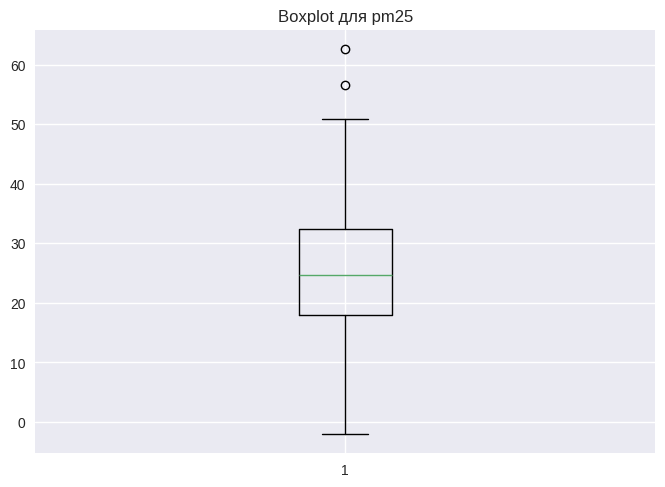

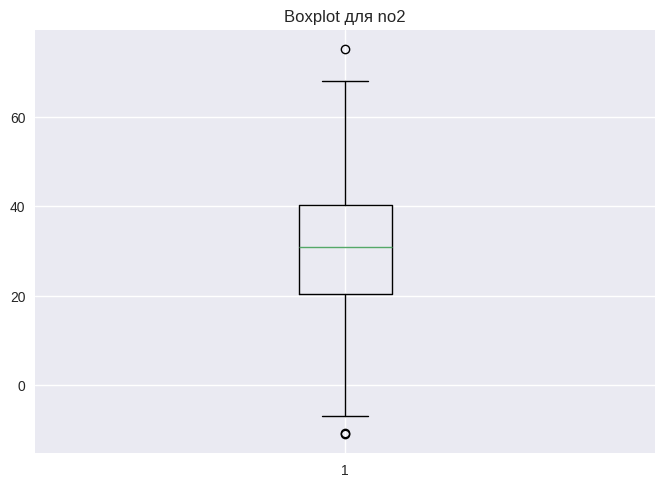

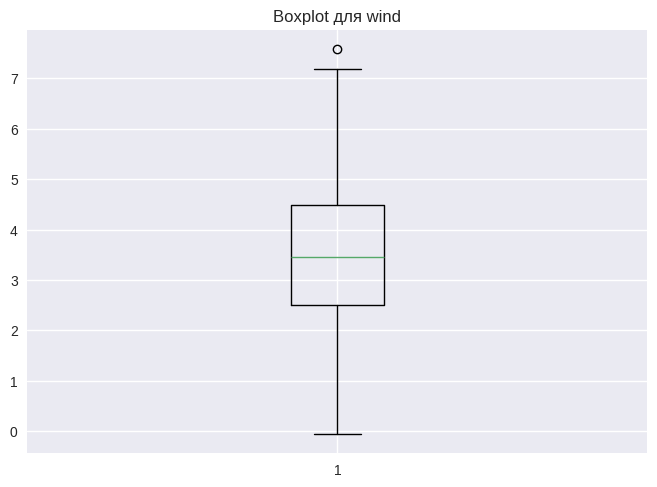

In [5]:
num_cols = data.select_dtypes(include=[np.number]).columns

for col in num_cols:
    plt.figure()
    plt.boxplot(data[col].dropna())
    plt.title(f"Boxplot для {col}")
    plt.show()

### Выявленные проблемы качества данных:

1) Наличие пропущенных значений

2) Наличие дубликатов

3) Наличие выбросов в числовых признаках

4) Возможные некорректные типы данных (если есть даты)

### 4. Очистка данных от дубликатов

In [6]:
rows_before = data.shape[0]

data = data.drop_duplicates()

rows_after = data.shape[0]

rows_before, rows_after

(376, 365)

Дубликаты не несут новой информации и могут искажать статистические характеристики.

## 5. Обработка пропущенных значений
### 5.1 Числовые признаки — замена медианой

In [7]:
for col in data.select_dtypes(include=[np.number]).columns:
    data[col] = data[col].fillna(data[col].median())

### 5.2 Категориальные признаки — замена модой

In [8]:
for col in data.select_dtypes(include=['object']).columns:
    data[col] = data[col].fillna(data[col].mode()[0])

Проверка:

In [9]:
data.isnull().sum()

pm25    0
no2     0
wind    0
dtype: int64

### Обоснование выбора стратегии:

1) Медиана устойчива к выбросам

2) Мода корректна для категориальных данных

3) Удаление строк привело бы к потере информации

## 6. Анализ и обработка выбросов (IQR)

In [10]:
def iqr_clean(df):
    res = df.copy()
    for col in res.select_dtypes(include=[np.number]).columns:
        q1 = res[col].quantile(0.25)
        q3 = res[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        res = res[(res[col] >= lower) & (res[col] <= upper)]
    return res

data_clean = iqr_clean(data)

data_clean.shape

(358, 3)

### Сравнение размера данных

In [11]:
data.shape, data_clean.shape

((365, 3), (358, 3))

Метод IQR позволяет удалить экстремальные значения, не характерные для основной выборки.

## 7. Преобразование и нормализация данных
### 7.1 Приведение дат (если есть столбцы с датами)
Если есть столбец типа date:

In [12]:
# data_clean['date'] = pd.to_datetime(data_clean['date'])

### 7.2 Нормализация числовых признаков (Z-score)

In [13]:
data_norm = data_clean.copy()

for col in data_norm.select_dtypes(include=[np.number]).columns:
    mean = data_norm[col].mean()
    std = data_norm[col].std()
    data_norm[col] = (data_norm[col] - mean) / std

data_norm.describe()

,pm25,no2,wind
count,3.580000e+02,3.580000e+02,3.580000e+02
mean,3.572561e-16,1.091616e-16,3.026753e-16
std,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.576595e+00,-2.605373e+00,-2.631280e+00
25%,-6.147328e-01,-6.591882e-01,-6.456940e-01
50%,1.846987e-02,4.566642e-02,6.962057e-03
75%,7.020750e-01,6.250994e-01,7.322040e-01
max,2.484648e+00,2.558904e+00,2.743598e+00


## 8. Сравнительный анализ «до / после»
### 8.1 Статистическое сравнение

In [14]:
print("До обработки:")
display(data_raw.describe())

print("После обработки:")
display(data_clean.describe())

До обработки:


,pm25,no2,wind
count,357.000000,358.000000,358.000000
mean,25.115138,30.232429,3.465544
std,11.029321,15.169746,1.389916
min,-2.012123,-10.959463,-0.055051
25%,18.009601,20.354392,2.502435
50%,24.613618,30.790824,3.459920
75%,32.401322,40.189967,4.486181
max,62.615984,75.169809,7.579868


После обработки:


,pm25,no2,wind
count,358.000000,358.000000,358.000000
mean,24.949398,30.127612,3.489414
std,10.464011,14.196288,1.347049
min,-2.012123,-6.859008,-0.055051
25%,18.516827,20.769586,2.619632
50%,25.142667,30.775905,3.498792
75%,32.295919,39.001703,4.475729
max,50.948788,66.454551,7.185176


### 8.2 Визуальное сравнение

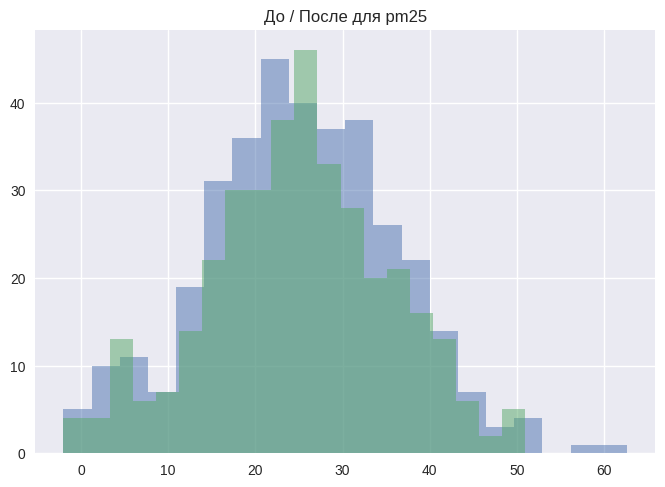

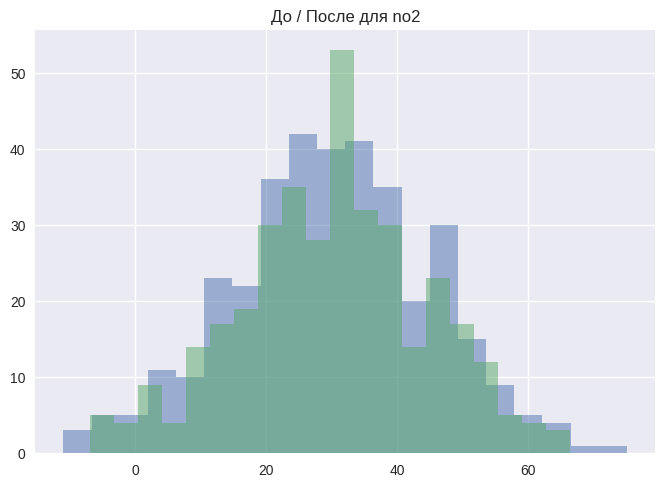

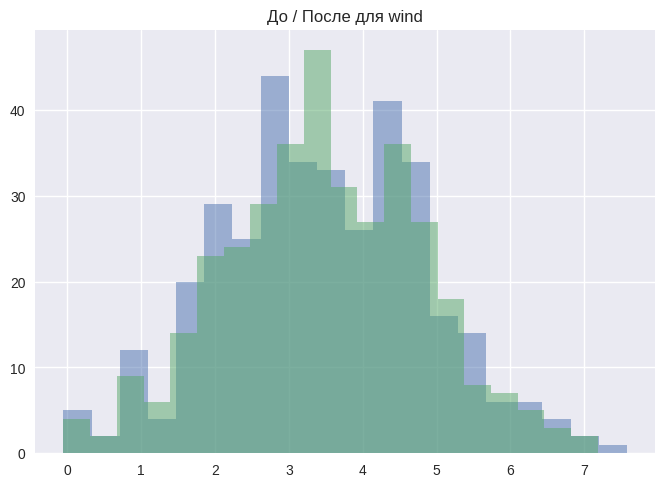

In [15]:
for col in data_clean.select_dtypes(include=[np.number]).columns:
    plt.figure()
    plt.hist(data_raw[col].dropna(), alpha=0.5, bins=20)
    plt.hist(data_clean[col], alpha=0.5, bins=20)
    plt.title(f"До / После для {col}")
    plt.show()

## 9. Итоговые выводы
В ходе выполнения практического занятия:

1) Были выявлены проблемы качества данных:

* пропущенные значения;

* дубликаты;

* выбросы.

2) Выполнены следующие шаги подготовки:

* удаление дубликатов;

* заполнение пропусков медианой и модой;

* удаление выбросов методом IQR;

* нормализация числовых признаков.

3) После обработки:

* уменьшилась размерность набора данных;

* стабилизировались статистические показатели;

* данные стали пригодны для последующего моделирования.

4) Ограничения:

* удаление выбросов может привести к потере редких, но реальных событий;

* замена пропусков медианой снижает вариативность признаков.